**Impact of Gaming Behavior on Academic and Psychological Outcomes**

> Big Data Analysis / Data Science Project by Akhmadjonov Sh



In [46]:
from google.colab import files
uploaded = files.upload()

Saving data_4.csv to data_4 (1).csv


In [47]:
import pandas as pd

df = pd.read_csv("data_4.csv")

In [48]:
from sklearn.preprocessing import OneHotEncoder
my_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform="pandas")

In [49]:
df.head()

,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,...,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,...,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,...,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,...,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,...,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1005 non-null   int64  
 1   gender                      1005 non-null   object 
 2   income                      1005 non-null   int64  
 3   daily_gaming_hours          1005 non-null   float64
 4   weekly_sessions             1005 non-null   int64  
 5   years_gaming                1005 non-null   int64  
 6   sleep_hours                 1005 non-null   float64
 7   caffeine_intake             1005 non-null   float64
 8   exercise_hours              1005 non-null   float64
 9   stress_level                1005 non-null   int64  
 10  anxiety_score               1005 non-null   float64
 11  depression_score            1005 non-null   float64
 12  social_interaction_score    1005 non-null   float64
 13  relationship_satisfaction   1005 

In [51]:
df.describe()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,...,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.00000
mean,35.942289,76684.697512,3.944657,19.523383,11.758209,6.992338,2.060537,1.999582,5.416915,4.830438,...,5.109453,4.976090,4.956468,5.999393,24.186219,7.925264,5.045990,3.982995,49.895522,5.60995
std,13.515988,41555.712105,2.877536,11.319372,7.206836,1.482334,2.054700,2.043844,2.865913,1.929894,...,3.157859,1.941267,1.993696,1.931674,3.986858,4.020046,1.972545,1.936471,28.836778,2.88441
min,13.000000,5025.000000,0.070000,1.000000,0.000000,2.940000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,11.070000,0.580000,0.000000,0.000000,0.000000,1.00000
25%,24.000000,40754.000000,1.790000,10.000000,5.000000,5.990000,0.580000,0.540000,3.000000,3.480000,...,2.000000,3.640000,3.620000,4.700000,21.500000,4.950000,3.700000,2.730000,26.000000,3.00000
50%,37.000000,75490.000000,3.290000,20.000000,12.000000,6.980000,1.390000,1.400000,5.000000,4.870000,...,5.000000,4.900000,5.030000,5.990000,24.150000,7.390000,5.070000,3.940000,49.000000,6.00000
75%,47.000000,112442.000000,5.460000,29.000000,18.000000,7.950000,2.870000,2.800000,8.000000,6.080000,...,8.000000,6.230000,6.240000,7.340000,26.800000,10.250000,6.380000,5.270000,75.000000,8.00000
max,59.000000,149698.000000,17.660000,39.000000,24.000000,11.490000,12.080000,15.800000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,37.030000,32.560000,10.000000,10.000000,99.000000,10.00000


In [52]:
df.isna().sum().sum()

np.int64(0)

We do not have any missing values xD

In [53]:
df.duplicated().sum()

np.int64(0)

Let's see how features in our data is correlated to each other.

In [54]:
df["gender"].value_counts()

,count
gender,
Female,487
Male,480
Other,38


Encoding "Gender Feature"

In [55]:
gender_transform = my_encoder.fit_transform(df[['gender']])
gender_transform.head()

,gender_Female,gender_Male,gender_Other
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


In [56]:
numeric_cols = df.select_dtypes(["number"]) #we stored all featues which are number only, from our data to numeric_cols variable

In [57]:
numeric_cols.corr()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
age,1.000000,-0.000228,-0.020407,-0.016443,0.036637,0.028225,0.016161,-0.025598,0.047240,0.025784,...,0.053774,0.012019,0.011233,-0.023995,-0.029560,-0.023387,0.001064,0.052590,0.015527,-0.020020
income,-0.000228,1.000000,0.052987,-0.023754,0.045455,0.017392,-0.032998,-0.028402,-0.024877,0.029381,...,0.029680,-0.023600,0.019798,-0.000770,0.015048,0.011805,-0.025650,-0.026007,-0.008277,0.049202
daily_gaming_hours,-0.020407,0.052987,1.000000,-0.052907,-0.016637,0.029801,-0.020572,-0.001875,0.016120,-0.011148,...,-0.035111,-0.051607,0.001994,0.039095,-0.043996,0.726846,-0.034936,-0.006680,-0.029179,0.054417
weekly_sessions,-0.016443,-0.023754,-0.052907,1.000000,-0.005236,-0.011382,-0.001359,0.020280,0.057160,0.007615,...,-0.005672,0.006377,-0.016248,0.024151,-0.019500,-0.026478,-0.047271,0.036714,-0.016410,-0.036175
years_gaming,0.036637,0.045455,-0.016637,-0.005236,1.000000,-0.012522,-0.026343,0.002770,-0.054429,0.044887,...,-0.012097,0.027038,0.007743,0.046036,0.001219,-0.032934,-0.010378,0.011515,-0.027612,0.054010
sleep_hours,0.028225,0.017392,0.029801,-0.011382,-0.012522,1.000000,-0.010239,0.002918,0.010717,0.068726,...,0.010559,-0.023220,0.004717,0.017947,-0.033936,0.027413,-0.003346,0.015829,-0.031946,-0.062268
caffeine_intake,0.016161,-0.032998,-0.020572,-0.001359,-0.026343,-0.010239,1.000000,-0.004110,0.011591,-0.007568,...,0.009257,0.035137,0.025412,0.066756,-0.055769,-0.009997,0.010728,0.011365,-0.056663,0.008773
exercise_hours,-0.025598,-0.028402,-0.001875,0.020280,0.002770,0.002918,-0.004110,1.000000,0.037767,-0.014742,...,0.012364,0.007805,-0.029841,-0.000434,-0.063440,0.014865,-0.047990,-0.015808,-0.005365,-0.019871
stress_level,0.047240,-0.024877,0.016120,0.057160,-0.054429,0.010717,0.011591,0.037767,1.000000,0.018132,...,0.005078,-0.010711,-0.016647,0.027558,0.018801,0.022045,-0.013943,-0.006089,-0.081329,-0.020311
anxiety_score,0.025784,0.029381,-0.011148,0.007615,0.044887,0.068726,-0.007568,-0.014742,0.018132,1.000000,...,-0.006135,0.020455,0.003760,-0.053172,-0.076416,-0.013983,-0.033127,-0.042226,-0.031593,0.036959


In [58]:
print(df["addiction_level"].quantile(0.33))
print(df["addiction_level"].quantile(0.66))

1.5832
3.4092


In [59]:
bins = [0, 1.5832, 3.4092, 10]
labels = ["Low", "Medium", "High"]

df["addiction_category"] = pd.cut(df["addiction_level"], bins=bins, labels=labels, include_lowest=True)

df["addiction_category"].head()

,addiction_category
0,Medium
1,High
2,Low
3,Medium
4,Medium


In [60]:
df["addiction_category"].shape

(1005,)

In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['addiction_category_encoded'] = le.fit_transform(df['addiction_category'])

I split the data into Training and Test before starting the preprocessing

In [62]:
x_reg = df[['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming', 'weekend_gaming_hours', 'sleep_hours', 'caffeine_intake', 'exercise_hours', 'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score', 'relationship_satisfaction', 'loneliness_score', 'aggression_score', 'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'streaming_hours', 'microtransactions_spending', 'friends_gaming_count', 'online_friends', 'competitive_rank', 'internet_quality', 'esports_interest', 'parental_supervision', 'addiction_level']]
x_reg = pd.concat([x_reg, gender_transform], axis=1)
y_reg = df['academic_performance']

Splitting for Regression Target

In [63]:
from sklearn.model_selection import train_test_split
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

print(x_train_reg.shape)
print(y_train_reg.shape)
print(x_test_reg.shape)
print(y_test_reg.shape)

(804, 33)
(804,)
(201, 33)
(201,)


In [64]:
x_train_reg.head()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,weekend_gaming_hours,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,friends_gaming_count,online_friends,competitive_rank,internet_quality,esports_interest,parental_supervision,addiction_level,gender_Female,gender_Male,gender_Other
78,35,92892,4.42,25,23,9.26,8.24,2.59,4.87,4,...,14,217,62,8,0,7,3.26,0.0,1.0,0.0
29,39,141414,1.02,38,5,2.77,5.28,0.48,1.55,9,...,8,383,24,3,7,2,0.80,1.0,0.0,0.0
280,23,74760,0.67,7,20,11.14,5.77,0.91,0.24,2,...,21,93,96,6,2,0,0.23,0.0,1.0,0.0
507,52,38418,1.03,29,23,8.06,5.22,4.87,0.72,3,...,18,408,57,8,5,5,1.38,0.0,0.0,1.0
652,45,56418,1.12,32,19,4.05,10.24,0.17,4.74,6,...,11,121,28,6,1,6,0.86,0.0,1.0,0.0


**Splitting for Classification**

In [65]:
x_clf = df[['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming', 'weekend_gaming_hours', 'sleep_hours', 'caffeine_intake', 'exercise_hours', 'stress_level', 'anxiety_score', 'depression_score', 'social_interaction_score', 'relationship_satisfaction', 'loneliness_score', 'aggression_score', 'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'streaming_hours', 'microtransactions_spending', 'friends_gaming_count', 'online_friends', 'competitive_rank', 'internet_quality', 'esports_interest', 'parental_supervision', 'academic_performance']]
y_clf = df['addiction_category_encoded']

x_clf = pd.concat([x_clf, gender_transform], axis=1)

In [66]:
x_train_clf, x_test_clf, y_train_clf, y_test_clf = train_test_split(x_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(x_train_clf.shape)
print(y_train_clf.shape)
print(x_test_clf.shape)
print(y_test_clf.shape)

(804, 33)
(804,)
(201, 33)
(201,)


In [67]:
x_train_clf.head()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,weekend_gaming_hours,sleep_hours,caffeine_intake,exercise_hours,stress_level,...,friends_gaming_count,online_friends,competitive_rank,internet_quality,esports_interest,parental_supervision,academic_performance,gender_Female,gender_Male,gender_Other
756,58,81360,5.44,7,14,2.70,8.71,0.12,0.23,6,...,19,410,96,3,4,9,63.97,1.0,0.0,0.0
306,19,130113,6.10,32,17,9.61,6.12,0.92,0.66,1,...,21,264,79,4,8,8,86.31,0.0,1.0,0.0
43,16,10752,2.08,1,3,4.35,6.54,8.22,0.76,9,...,11,13,44,2,9,10,71.69,1.0,0.0,0.0
851,38,79874,4.24,10,17,6.30,6.16,2.25,2.82,5,...,17,218,21,8,8,10,77.77,0.0,1.0,0.0
95,19,24868,0.44,2,11,6.30,8.62,1.58,2.93,2,...,40,192,99,9,8,8,51.26,1.0,0.0,0.0


In [68]:
y_train_clf.head()

,addiction_category_encoded
756,0
306,0
43,1
851,2
95,1


In [69]:
y_test_clf.head()

,addiction_category_encoded
990,0
294,2
432,1
429,1
833,2


In [70]:
print(x_train_reg.shape)
print(y_train_reg.shape)
print(x_test_clf.shape)
print(y_test_clf.shape)

(804, 33)
(804,)
(201, 33)
(201,)


**Data Visualization** - 5 visuals

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

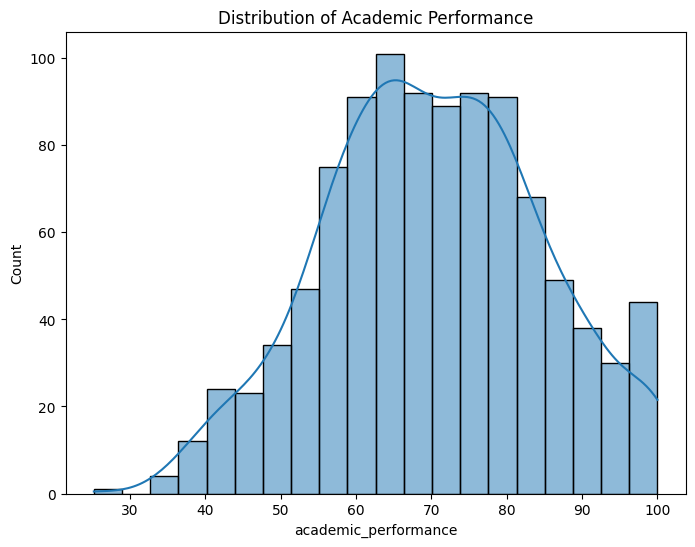

In [72]:
plt.figure(figsize=(8, 6))
sns.histplot(df['academic_performance'], bins=20, kde=True)
plt.title('Distribution of Academic Performance')
plt.show()

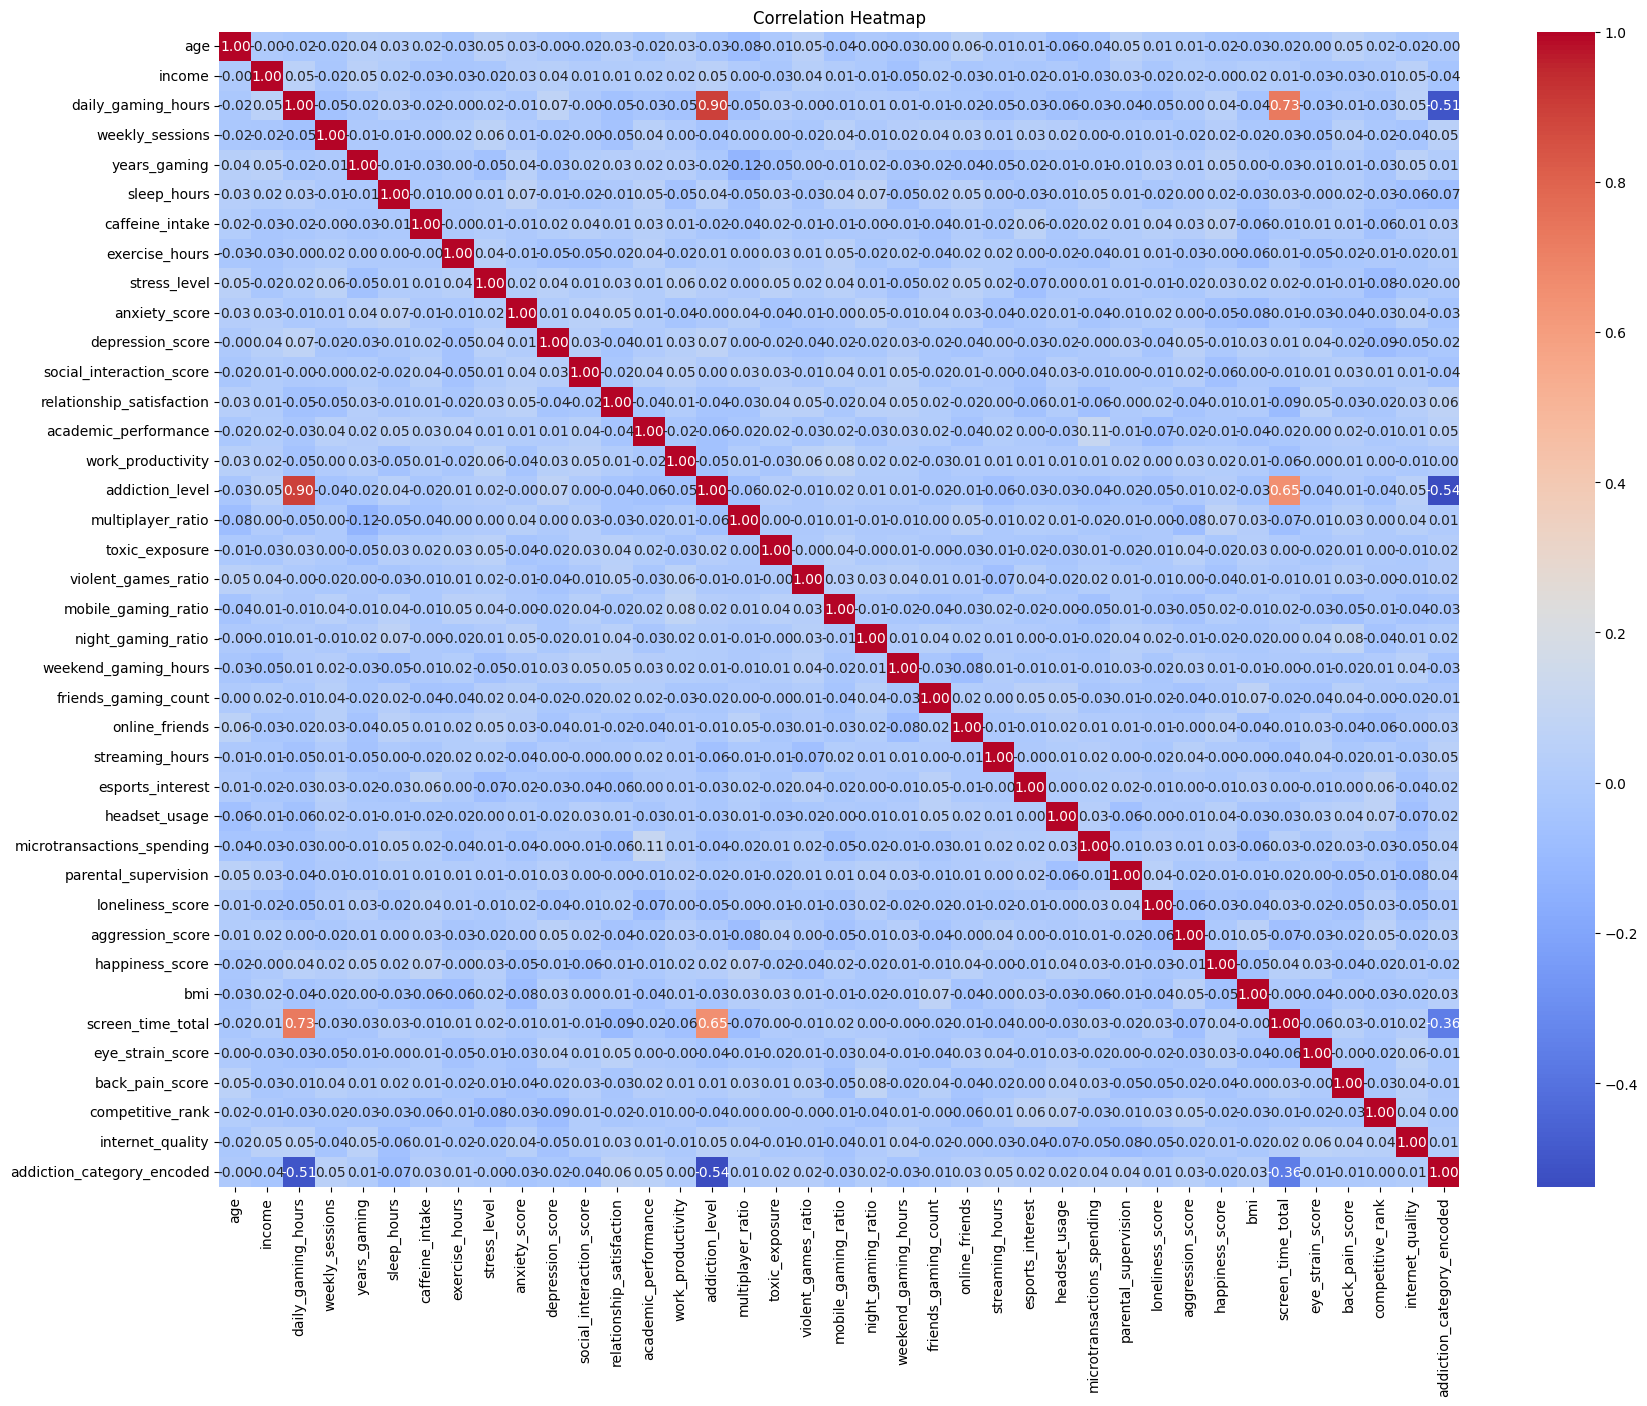

In [73]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

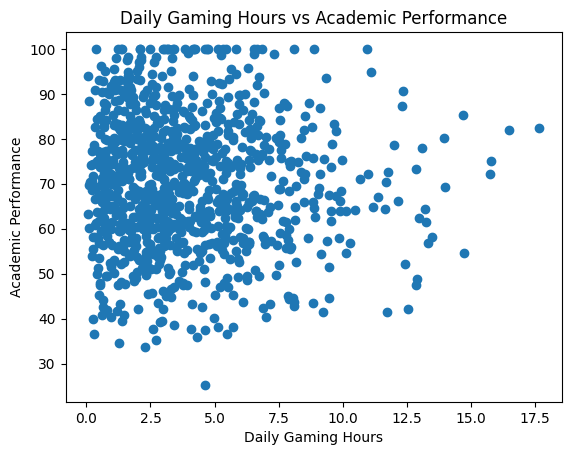

In [74]:
x = df["daily_gaming_hours"]
y = df["academic_performance"]
plt.scatter(x, y)
plt.title("Daily Gaming Hours vs Academic Performance")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Academic Performance")

plt.show()

Text(0.5, 0.98, 'Academic Performance by Addiction Category')

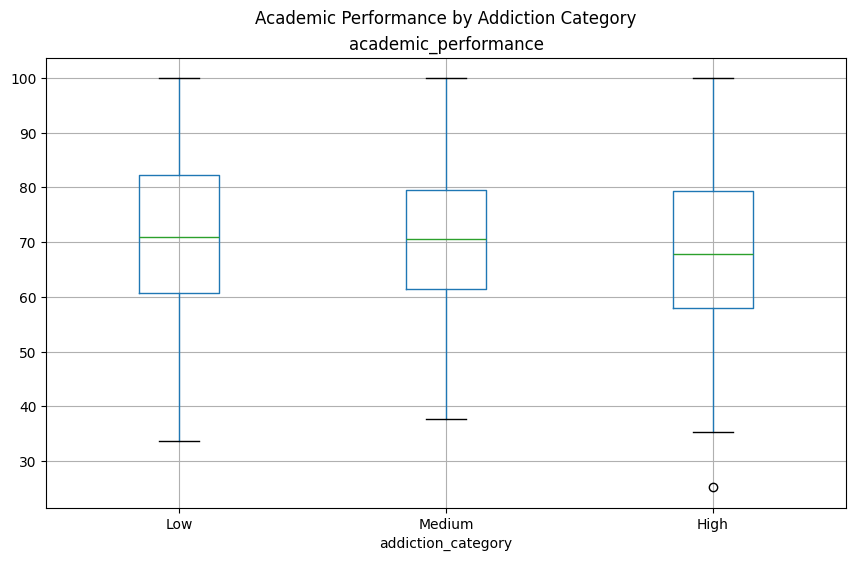

In [75]:
g_boxplot = df.boxplot(column="academic_performance", by="addiction_category", figsize=(10,6))
g_boxplot.set_ylabel = "Academic Performance"
g_boxplot.set_xlabel = "Addiction Category"
plt.suptitle("Academic Performance by Addiction Category")

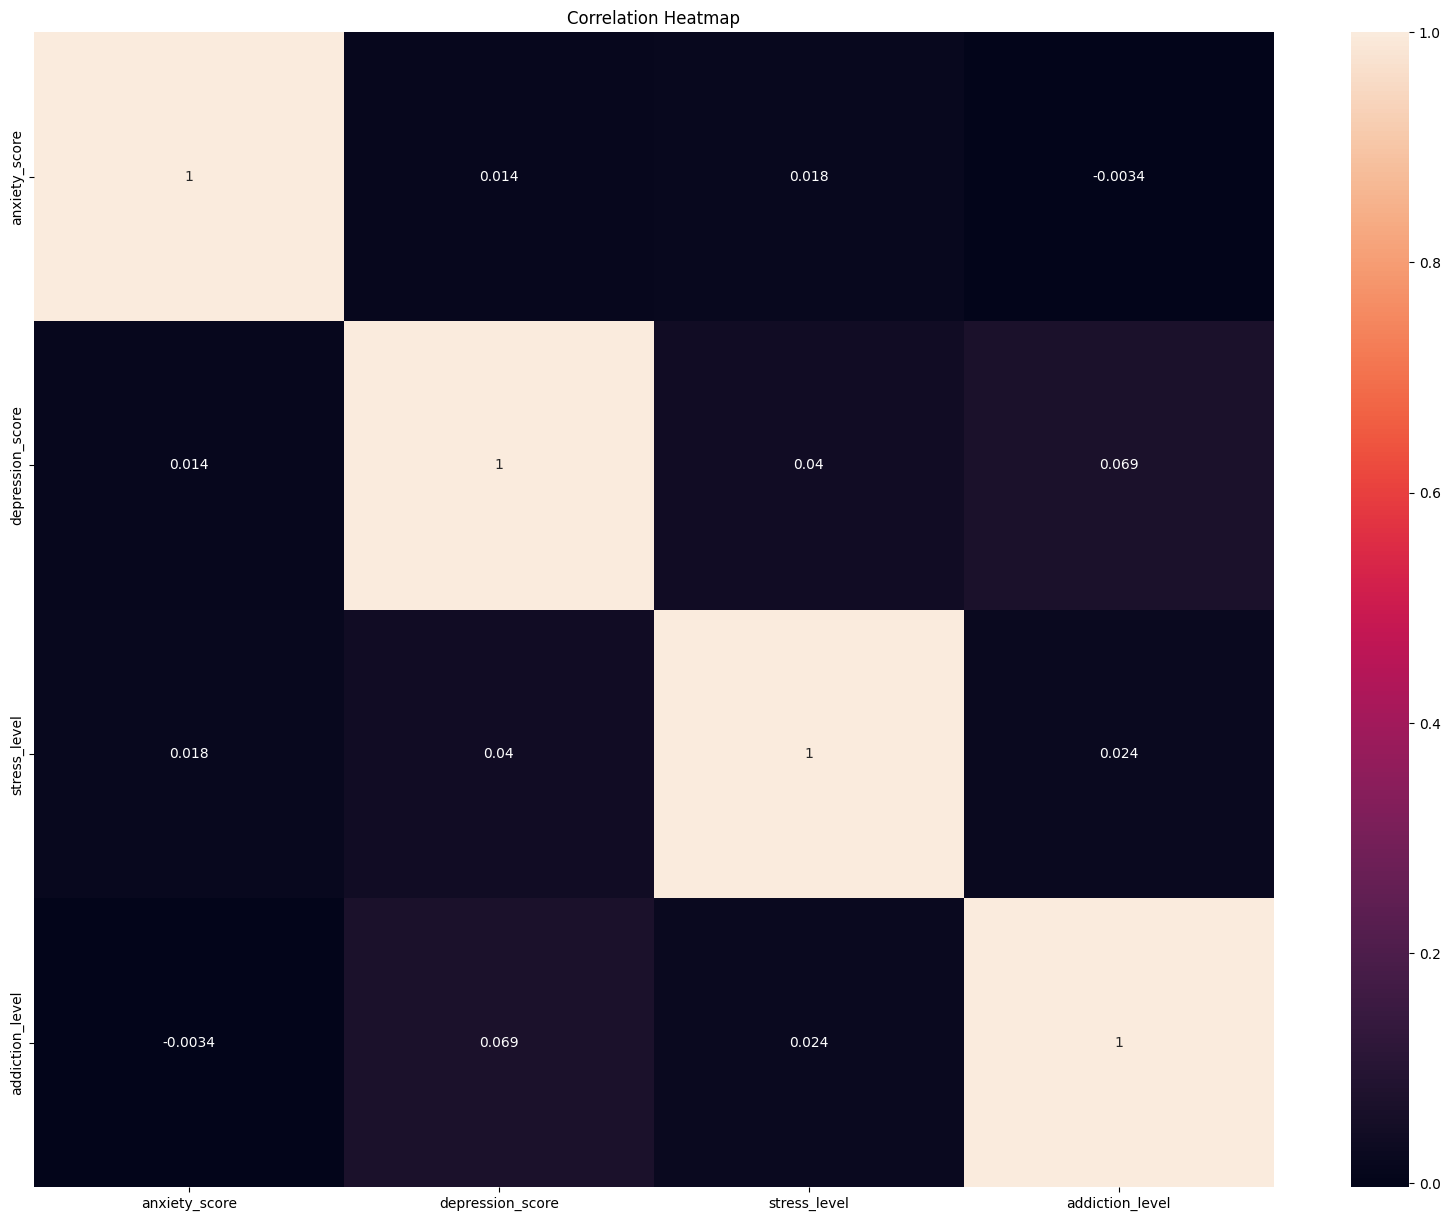

In [76]:
plt.figure(figsize=(20,15))
sns.heatmap(df[["anxiety_score", "depression_score", "stress_level", "addiction_level"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [77]:
from sklearn.preprocessing import StandardScaler

I use scaler for X Train/Test Regression and Classification. So, I need to use 2 times.

In [78]:
scale_reg = StandardScaler()

x_train_reg_scaled = scale_reg.fit_transform(x_train_reg)
x_test_reg_scaled = scale_reg.transform(x_test_reg)

In [79]:
scale_clf = StandardScaler()

x_train_clf_scaled = scale_clf.fit_transform(x_train_clf)
x_test_clf_scaled = scale_clf.transform(x_test_clf)

Clustering starts here

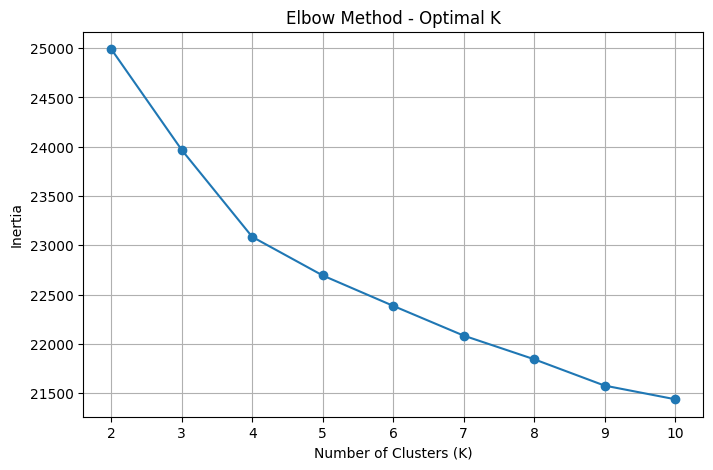

In [80]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_train_reg_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [81]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(x_train_reg_scaled)


import numpy as np
from sklearn.preprocessing import StandardScaler


x_reg_full_scaled = scale_reg.transform(x_reg)

all_cluster_labels = kmeans.predict(x_reg_full_scaled)

df_cluster = df.copy()
df_cluster['kmeans_cluster'] = all_cluster_labels

print(df_cluster['kmeans_cluster'].value_counts())

kmeans_cluster
2    428
1    411
0    166
Name: count, dtype: int64


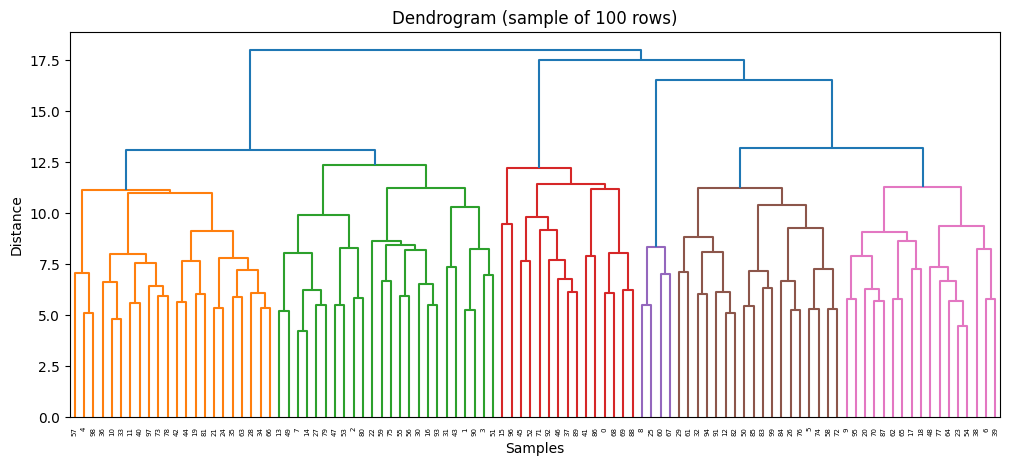

hc_cluster
1    513
0    454
2     38
Name: count, dtype: int64


In [82]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12, 5))
sch.dendrogram(sch.linkage(x_reg_full_scaled[:100], method='ward'))
plt.title('Dendrogram (sample of 100 rows)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')


hc_labels = hc.fit_predict(x_reg_full_scaled)

df_cluster['hc_cluster'] = hc_labels
print(df_cluster['hc_cluster'].value_counts())

Regression steps...

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(x_train_reg_scaled, y_train_reg)

y_pred_lr = lr.predict(x_test_reg_scaled)

print("=== Linear Regression ===")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)))
print("R²  :", r2_score(y_test_reg, y_pred_lr))

=== Linear Regression ===
MAE : 11.382156745419113
RMSE: 14.212989809677026
R²  : -0.04643706759657218


In [84]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(x_train_reg_scaled, y_train_reg)

y_pred_rf_reg = rf_reg.predict(x_test_reg_scaled)

print("=== Random Forest Regression ===")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_rf_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)))
print("R²  :", r2_score(y_test_reg, y_pred_rf_reg))

=== Random Forest Regression ===
MAE : 11.286743781094529
RMSE: 14.22945829220152
R²  : -0.04886346975372291


Classification

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(x_train_clf_scaled, y_train_clf)

y_pred_log = log_clf.predict(x_test_clf_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_log))
print(classification_report(y_test_clf, y_pred_log, target_names=['Low', 'Medium', 'High']))

=== Logistic Regression ===
Accuracy: 0.6716417910447762
              precision    recall  f1-score   support

         Low       0.75      0.84      0.79        69
      Medium       0.71      0.74      0.73        66
        High       0.51      0.42      0.46        66

    accuracy                           0.67       201
   macro avg       0.66      0.67      0.66       201
weighted avg       0.66      0.67      0.66       201



In [86]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(x_train_clf_scaled, y_train_clf)

y_pred_rf_clf = rf_clf.predict(x_test_clf_scaled)

print("=== Random Forest Classification ===")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_rf_clf))
print(classification_report(y_test_clf, y_pred_rf_clf, target_names=['Low', 'Medium', 'High']))

=== Random Forest Classification ===
Accuracy: 0.6467661691542289
              precision    recall  f1-score   support

         Low       0.73      0.80      0.76        69
      Medium       0.68      0.82      0.74        66
        High       0.45      0.32      0.37        66

    accuracy                           0.65       201
   macro avg       0.62      0.64      0.63       201
weighted avg       0.62      0.65      0.63       201



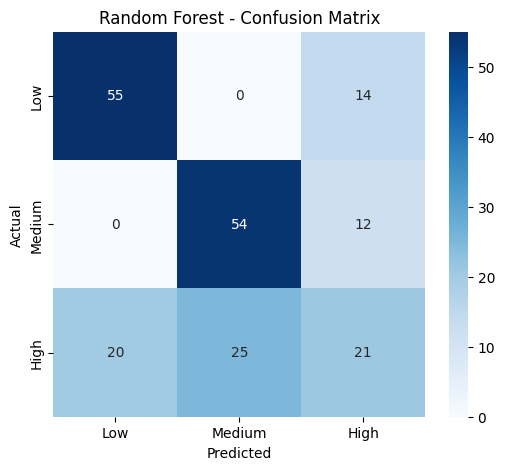

In [87]:
cm = confusion_matrix(y_test_clf, y_pred_rf_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Model Evaluation Summary

In [88]:
# ============================================================
# MODEL EVALUATION SUMMARY
# ============================================================

print("=" * 55)
print("       REGRESSION RESULTS (Predict: academic_performance)")
print("=" * 55)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
print(f"{'Linear Regression':<25} {mean_absolute_error(y_test_reg, y_pred_lr):>8.3f} {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):>8.3f} {r2_score(y_test_reg, y_pred_lr):>8.3f}")
print(f"{'Random Forest Reg.':<25} {mean_absolute_error(y_test_reg, y_pred_rf_reg):>8.3f} {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)):>8.3f} {r2_score(y_test_reg, y_pred_rf_reg):>8.3f}")

print()
print("=" * 55)
print("  CLASSIFICATION RESULTS (Predict: addiction_category)")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 55)
print(f"{'Logistic Regression':<25} {accuracy_score(y_test_clf, y_pred_log):>10.4f}")
print(f"{'Random Forest Clf.':<25} {accuracy_score(y_test_clf, y_pred_rf_clf):>10.4f}")

print()
print("=" * 55)
print("  CLUSTERING SUMMARY")
print("=" * 55)
print("K-Means cluster distribution:")
print(df_cluster['kmeans_cluster'].value_counts().sort_index())
print()
print("Hierarchical cluster distribution:")
print(df_cluster['hc_cluster'].value_counts().sort_index())

       REGRESSION RESULTS (Predict: academic_performance)
Model                          MAE     RMSE       R²
-------------------------------------------------------
Linear Regression           11.382   14.213   -0.046
Random Forest Reg.          11.287   14.229   -0.049

  CLASSIFICATION RESULTS (Predict: addiction_category)
Model                       Accuracy
-------------------------------------------------------
Logistic Regression           0.6716
Random Forest Clf.            0.6468

  CLUSTERING SUMMARY
K-Means cluster distribution:
kmeans_cluster
0    166
1    411
2    428
Name: count, dtype: int64

Hierarchical cluster distribution:
hc_cluster
0    454
1    513
2     38
Name: count, dtype: int64


## Conclusions

**Regression findings:**
Both Linear Regression and Random Forest Regression produced a negative R² score,
indicating that academic performance cannot be reliably predicted from gaming
behavior features alone. This aligns with the low correlation values observed
in the EDA phase, gaming habits have weak linear relationships with academic outcomes.

**Classification findings:**
Logistic Regression (67.2%) outperformed Random Forest (64.7%) in predicting
addiction category. Both models performed best on the "Low" class and worst on
the "High" class, which suggests highly addicted users display more varied behavioral
patterns that are harder to capture.

**Clustering findings:**
K-Means produced three relatively balanced clusters, while Hierarchical Clustering
identified one very small cluster (38 rows) suggesting a small subgroup of users
with highly distinct gaming behavior patterns.